# 4. Slug test for confined aquifer - Dawsonville

### Import packages

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import timflow.transient as tft

plt.rcParams["figure.figsize"] = [5, 3]

### Introduction and Conceptual Model

This Slug Test, was reported by Cooper Jr et al. (1967), and it was performed in Dawsonville, Georgia, USA. 

A fully penetrated well (Ln-2) is screened in a confined aquifer, located between depths 24 and 122 (98 m thick). The volume of the slug is 10.16 litres. Head change has been recorded at the slug well. Both the well and the casing radii of the slug well is 0.076 m.

<img src="./figs/Dawsonville.png" style="width:400pt">

### Load data

In [2]:
data = np.loadtxt("data/dawsonville_slug.txt")
to = data[:, 0]
ho = data[:, 1]

### Parameters and model

In [3]:
# known parameters
b = 98  # aquifer thickness in m
zt = -24  # top of aquifer in m
zb = zt - b  # bottom of aquifer in m
rw = 0.076  # well radius of Ln-2 Well in m
rc = 0.076  # casing radius of Ln-2 Well in m
Q = 10.16 / 1000  # slug volume in m^3 (10.16 l = 0.01016 m^3)

In [4]:
ml = tft.ModelMaq(kaq=10, z=[zt, zb], Saq=1e-4, tmin=1e-6, tmax=1e-3, topboundary="conf")
w = tft.Well(ml, xw=0, yw=0, rw=rw, rc=rc, tsandQ=[(0, -Q)], layers=0, wbstype="slug")
ml.solve()

self.neq  1
solution complete


### Estimate aquifer parameters

We calibrate hydraulic conductivity and specific storage, as in the KGS model (Hyder et al. 1994).

In [5]:
# unknown parameters: kay, Saq
cal = tft.Calibrate(ml)
cal.set_parameter(name="kaq0", initial=10, pmin=0, layers=0)
cal.set_parameter(name="Saq0", initial=1e-4, layers=0)
cal.seriesinwell(name="obs", element=w, t=to, h=ho)
cal.fit(report=False)

...............................
Fit succeeded.


In [6]:
display(cal.parameters)
print("rmse:", cal.rmse())

,layers,optimal,pmin,pmax,initial,inhoms,parray
kaq0_0_0,0,0.420908,0.0,inf,10.0000,None,[[0.42090788883700814]]
Saq0_0_0,0,0.000017,-inf,inf,0.0001,None,[[1.7004312750679313e-05]]


rmse: 0.004409616694582213


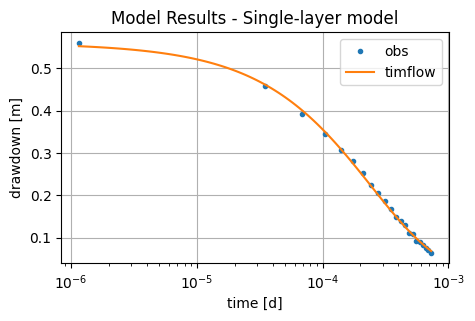

In [7]:
tm = np.logspace(np.log10(to[0]), np.log10(to[-1]), 100)
hm = ml.head(0, 0, tm)
plt.semilogx(to, ho, ".", label="obs")
plt.semilogx(tm, hm[0], label="timflow")
plt.xlabel("time [d]")
plt.ylabel("drawdown [m]")
plt.title("Model Results - Single-layer model")
plt.legend()
plt.grid()

### Comparison of results

We now compare the values in `timflow` and add the results of the modelling done in MLU (Hemker & Post, 2014). Results are similar between both models. The RMSE of MLU is slightly better than the one from `timflow`.

In [8]:
t = pd.DataFrame(
    columns=["k [m/d]", "Ss [1/m]", "RMSE [m]"],
    index=["timflow", "MLU"],
)

t.loc["timflow"] = np.append(cal.parameters["optimal"].values, cal.rmse())
t.loc["MLU"] = [0.4133, 1.9388e-05, 0.004264]

t_formatted = t.style.format(
    {"k [m/d]": "{:.2f}", "Ss [1/m]": "{:.2e}", "RMSE [m]": "{:.3f}"}
)
t_formatted

,k [m/d],Ss [1/m],RMSE [m]
timflow,0.42,1.70e-05,0.004
MLU,0.41,1.94e-05,0.004


### References

* Cooper Jr, H.H., Bredehoeft, J.D. and Papadopulos, I.S. (1967) Response of a finite diameter well to an instantaneous charge of water, Water Resources Research 3, 263–269
* Duffield, G.M. (2007), AQTESOLV for Windows Version 4.5 User's Guide, HydroSOLVE, Inc., Reston, VA.
* Hemker, K. en Post V. (2014) MLU for Windows: well flow modeling in multilayer aquifer systems; MLU User's guide. https://eur03.safelinks.protection.outlook.com/?url=https%3A%2F%2Fmicrofem.com%2Fdownload%2Fmlu-user.pdf&data=05%7C02%7CMark.Bakker%40tudelft.nl%7Cad7f16364d2d4fd55dbf08de73832eaa%7C096e524d692940308cd38ab42de0887b%7C0%7C0%7C639075204580287861%7CUnknown%7CTWFpbGZsb3d8eyJFbXB0eU1hcGkiOnRydWUsIlYiOiIwLjAuMDAwMCIsIlAiOiJXaW4zMiIsIkFOIjoiTWFpbCIsIldUIjoyfQ%3D%3D%7C0%7C%7C%7C&sdata=OBoe8seXZUfoat89Dfr4g6lF%2Bn1FdtXqtp%2F18BMXCn0%3D&reserved=0
* Hyder, Z., Butler Jr, J.J., McElwee, C.D. and Liu, W. (1994) Slug tests in partially penetrating wells, Water Resources Research 30, 2945–2957.